# 01 · Análisis exploratorio (EDA)
**High Garden Coffee** · Consumo doméstico de café, 1990/91 – 2019/20

**Objetivo:** entender la estructura y la calidad del dato, tomar decisiones explícitas de limpieza y dejar un dataset en formato largo listo para los notebooks de pronóstico, segmentación y oportunidad.

**Salida:** `outputs/coffee_long.parquet`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import *

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.2f}".format

## 1. Estructura del dato

In [2]:
wide = load_wide()
seasons = season_cols(wide)
print(f"{wide.shape[0]} países × {len(seasons)} temporadas ({seasons[0]} → {seasons[-1]})")
wide.iloc[:5, :6]

55 países × 30 temporadas (1990/91 → 2019/20)


,Country,Coffee type,1990/91,1991/92,1992/93,1993/94
0,Angola,Robusta/Arabica,1200000,1800000,2100000,1200000
1,Bolivia (Plurinational State of),Arabica,1500000,1620000,1650000,1710000
2,Brazil,Arabica/Robusta,492000000,510000000,534000000,546000000
3,Burundi,Arabica/Robusta,120000,96000,102000,114600
4,Ecuador,Arabica/Robusta,21000000,21000000,21000000,21000000


## 2. Calidad de datos

In [3]:
print("Nulos:", int(wide.isna().sum().sum()))
print("Países duplicados:", int(wide["Country"].duplicated().sum()))
print("Total_domestic_consumption = suma de temporadas:",
      bool((wide[seasons].sum(axis=1) == wide["Total_domestic_consumption"]).all()))
print()
print(wide["Coffee type"].value_counts().to_string())

Nulos: 0
Países duplicados: 0
Total_domestic_consumption = suma de temporadas: True

Coffee type
Arabica            22
Robusta            15
Robusta/Arabica    10
Arabica/Robusta     8


### Ceros
Hay ceros en 7 países. Veamos si son ceros reales o datos ausentes: `·` = 0 y `█` = dato, de 1990/91 a 2019/20.

In [4]:
mat = wide.set_index("Country")[seasons]
con_ceros = mat[(mat == 0).any(axis=1)]
patron = con_ceros.apply(lambda r: "".join("·" if v == 0 else "█" for v in r), axis=1)
patron.rename("patrón").to_frame()

,patrón
Country,
Timor-Leste,····················██████████
Zambia,███████████████████···········
Equatorial Guinea,······························
Guyana,········██████████████████████
Lao People's Democratic Republic,············██████████████████
Nepal,······························
Yemen,·············█████████████████


- **Ceros iniciales** (Timor-Leste, Guyana, Laos, Yemen): el país entra al dataset más tarde. Son datos ausentes, no consumo cero.
- **Ceros finales** (Zambia): la serie se corta en 2008/09.
- **Todo cero** (Nepal, Guinea Ecuatorial): sin información.

### Unidad de medida
El enunciado habla de *tazas*, pero el archivo no declara unidad. Un chequeo de orden de magnitud con Brasil:

In [5]:
brasil = wide.loc[wide["Country"] == "Brazil", "2019/20"].iat[0]
print(f"Brasil 2019/20 = {brasil:,.0f}")
print(f"Si la unidad fuera kg → ≈ {brasil / 60e6:,.1f} M de sacos de 60 kg")

Brasil 2019/20 = 1,320,000,000
Si la unidad fuera kg → ≈ 22.0 M de sacos de 60 kg


Ese valor es consistente con el consumo doméstico de Brasil reportado en sacos de 60 kg, así que la unidad **probablemente son kg**, no tazas. Es un supuesto que hay que declarar: en todo el análisis se trabaja en *millones de unidades originales* y las conclusiones son relativas (crecimiento, participación, ranking), no dependen de la unidad.

### ¿Qué países son?

In [6]:
print(", ".join(sorted(wide["Country"].replace(SHORT_NAMES))))

Angola, Bolivia, Brazil, Burundi, Cameroon, Central African Republic, Colombia, Congo, Costa Rica, Cuba, Côte d'Ivoire, Dominican Republic, Ecuador, El Salvador, Equatorial Guinea, Ethiopia, Gabon, Ghana, Guatemala, Guinea, Guyana, Haiti, Honduras, India, Indonesia, Jamaica, Kenya, Laos, Liberia, Madagascar, Malawi, Mexico, Nepal, Nicaragua, Nigeria, Panama, Papua New Guinea, Paraguay, Peru, Philippines, RD Congo, Rwanda, Sierra Leone, Sri Lanka, Tanzania, Thailand, Timor-Leste, Togo, Trinidad y Tobago, Uganda, Venezuela, Vietnam, Yemen, Zambia, Zimbabwe


Son países **productores/exportadores** (Brasil, Colombia, Etiopía, Indonesia, Vietnam…). No aparecen los grandes importadores (EE. UU., Alemania, Japón). Por lo tanto el dataset habla del **consumo interno de los países productores**, no de la demanda de importación. Esto condiciona la lectura de "oportunidad" en el notebook 04.

## 3. Decisiones de limpieza

| Tema | Decisión | Razón |
|---|---|---|
| Unidad | Trabajar en millones de unidades originales | La unidad no está declarada |
| Formato | Pasar a formato largo (país–temporada) | Facilita gráficos y modelos |
| Año | `year` = año de inicio de la temporada (1990/91 → 1990) | Índice numérico limpio |
| Tipo de café | Agrupar `Robusta/Arabica` y `Arabica/Robusta` como **Mixto** | Son casi la misma categoría |
| Ceros | Modelar solo países con ≥ 15 temporadas positivas consecutivas hasta 2019/20 | Los ceros son datos ausentes, no consumo real |
| Ceros iniciales | Recortar la serie desde el primer valor positivo | No inventar historia |
| Series planas | No excluir; marcar con `flat_share` como bandera de confianza | Ver sección 3b |

In [7]:
long = to_long(wide)
universe = modelable_countries(long)
long["in_universe"] = long["country"].isin(universe)

excluidos = sorted(set(long["country"]) - set(universe))
print(f"Universo de modelado: {len(universe)} países")
print("Excluidos:", ", ".join(excluidos))

long.to_parquet(OUT / "coffee_long.parquet", index=False)
long.head()

Universo de modelado: 51 países
Excluidos: Equatorial Guinea, Nepal, Timor-Leste, Zambia


,country,coffee_type,season,consumption,year,coffee_group,consumption_m,in_universe
0,Angola,Robusta/Arabica,1990/91,1200000,1990,Mixto,1.20,True
1,Angola,Robusta/Arabica,1991/92,1800000,1991,Mixto,1.80,True
2,Angola,Robusta/Arabica,1992/93,2100000,1992,Mixto,2.10,True
3,Angola,Robusta/Arabica,1993/94,1200000,1993,Mixto,1.20,True
4,Angola,Robusta/Arabica,1994/95,1500000,1994,Mixto,1.50,True


### 3b. Series planas
Antes de modelar conviene saber cuánta variación real hay. Miramos qué proporción de los cambios año a año es **exactamente cero**.

Variaciones anuales exactamente iguales a 0: 55.2%
Países con ≥70% de años planos: 21 de 51  (pesan 3.5% del consumo 2019/20)


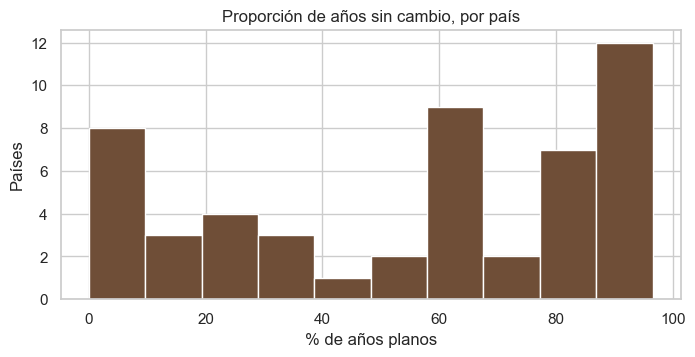

In [8]:
d = long[long["in_universe"]].sort_values(["country", "year"]).copy()
d["chg"] = d.groupby("country")["consumption"].diff()
d = d.dropna(subset=["chg"])

quality = (d.groupby("country")["chg"].apply(lambda s: (s == 0).mean())
             .rename("flat_share").reset_index())
quality.to_parquet(OUT / "country_quality.parquet", index=False)

peso_2019 = long[long["year"] == 2019].set_index("country")["consumption_m"]
muy_planos = quality.loc[quality["flat_share"] >= 0.7, "country"]

print(f"Variaciones anuales exactamente iguales a 0: {(d['chg'] == 0).mean():.1%}")
print(f"Países con ≥70% de años planos: {len(muy_planos)} de {len(universe)}  "
      f"(pesan {peso_2019[muy_planos].sum() / peso_2019.sum():.1%} del consumo 2019/20)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(quality["flat_share"] * 100, bins=10, color="#6f4e37", edgecolor="white")
ax.set(title="Proporción de años sin cambio, por país", xlabel="% de años planos", ylabel="Países")
save_fig("eda_series_planas")
plt.show()

Más de la mitad de las variaciones son cero: muchos valores parecen **estimaciones arrastradas** más que mediciones anuales. Consecuencias que se tendrán en cuenta más adelante:
- El baseline ingenuo (repetir el último valor) va a ser difícil de superar en esos países.
- Un pronóstico plano con intervalo estrecho **no significa certeza**, sino falta de información. Se usará `flat_share` como bandera de confianza en el ranking final.

## 4. Tendencia global

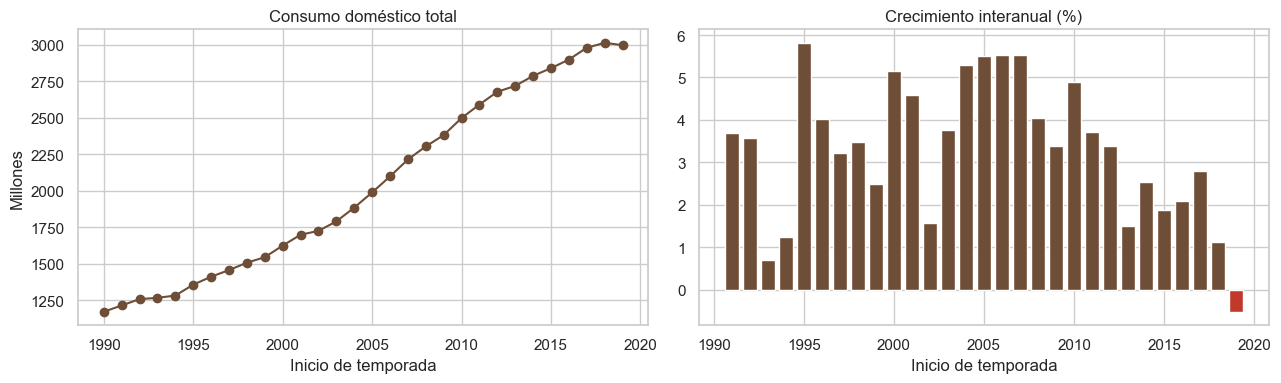

Total 1990: 1,171 M  →  2019: 2,999 M  (x2.56)
CAGR 1990–2019: 3.30%
CAGR últimos 5 años: 1.47%


In [9]:
tot = long.groupby("year")["consumption_m"].sum()
yoy = tot.pct_change() * 100

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(tot.index, tot.values, marker="o", color="#6f4e37")
ax[0].set(title="Consumo doméstico total", xlabel="Inicio de temporada", ylabel="Millones")
ax[1].bar(yoy.index, yoy.values, color=np.where(yoy.values >= 0, "#6f4e37", "#c0392b"))
ax[1].set(title="Crecimiento interanual (%)", xlabel="Inicio de temporada")
plt.tight_layout()
save_fig("eda_tendencia_global")
plt.show()

print(f"Total {tot.index[0]}: {tot.iloc[0]:,.0f} M  →  {tot.index[-1]}: {tot.iloc[-1]:,.0f} M  (x{tot.iloc[-1]/tot.iloc[0]:.2f})")
print(f"CAGR 1990–2019: {(tot.iloc[-1]/tot.iloc[0])**(1/(len(tot)-1))-1:.2%}")
print(f"CAGR últimos 5 años: {(tot.iloc[-1]/tot.iloc[-6])**(1/5)-1:.2%}")

## 5. Concentración del consumo

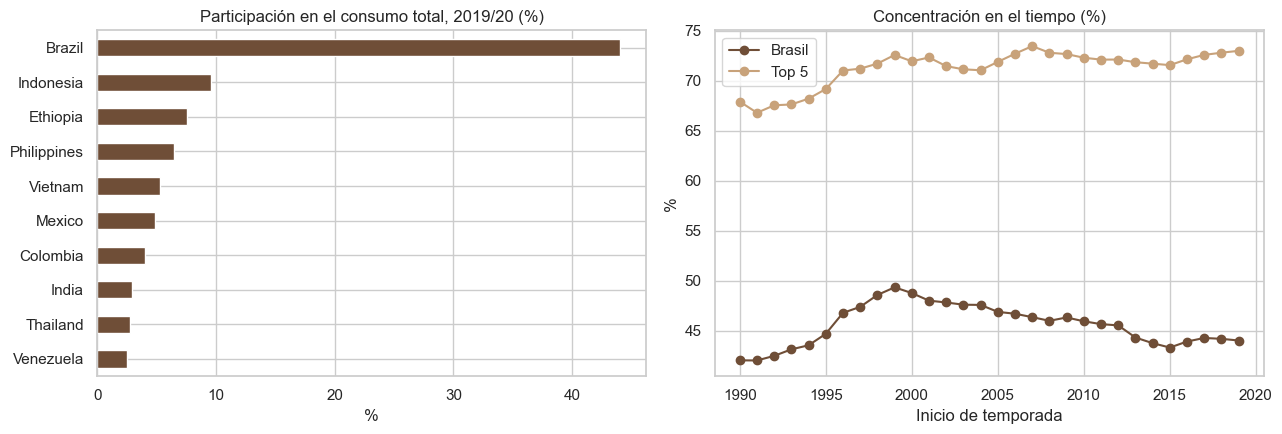

Brasil: 44.0% · Top 5: 73.0% · Top 10: 90.2%


In [10]:
piv = long.pivot(index="year", columns="country", values="consumption_m")
last = piv.loc[2019].sort_values(ascending=False)
share = last / last.sum() * 100

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
share.head(10).sort_values().plot.barh(ax=ax[0], color="#6f4e37")
ax[0].set(title="Participación en el consumo total, 2019/20 (%)", xlabel="%", ylabel="")

top5 = piv.apply(lambda r: r.nlargest(5).sum() / r.sum(), axis=1) * 100
(piv["Brazil"] / piv.sum(axis=1) * 100).plot(ax=ax[1], label="Brasil", color="#6f4e37", marker="o")
top5.plot(ax=ax[1], label="Top 5", color="#c8a27a", marker="o")
ax[1].set(title="Concentración en el tiempo (%)", xlabel="Inicio de temporada", ylabel="%")
ax[1].legend()
plt.tight_layout()
save_fig("eda_concentracion")
plt.show()

print(f"Brasil: {share['Brazil']:.1f}% · Top 5: {share.head(5).sum():.1f}% · Top 10: {share.head(10).sum():.1f}%")

## 6. Por tipo de café

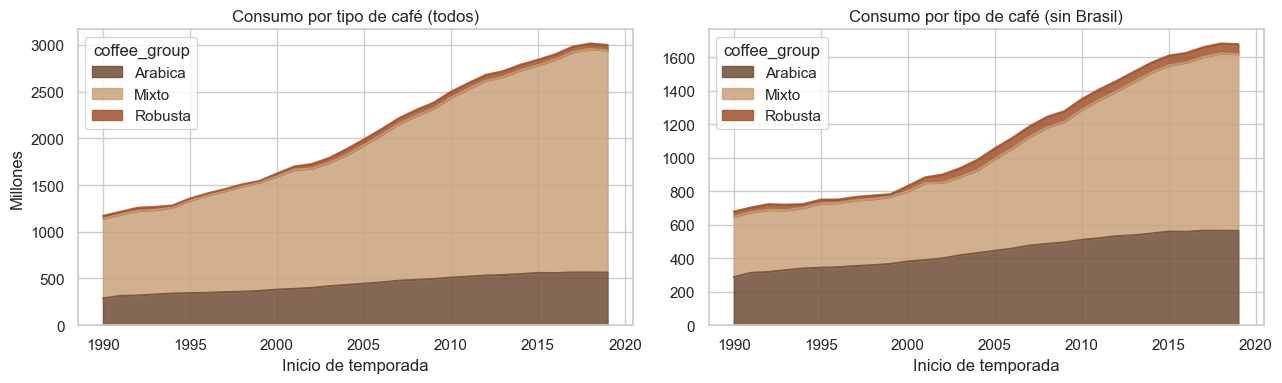

coffee_group
Arabica    22
Mixto      18
Robusta    15


In [11]:
grp = long.pivot_table(index="year", columns="coffee_group", values="consumption_m", aggfunc="sum")
grp_sin_br = long[long["country"] != "Brazil"].pivot_table(
    index="year", columns="coffee_group", values="consumption_m", aggfunc="sum")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
grp.plot.area(ax=ax[0], alpha=0.85, color=["#6f4e37", "#c8a27a", "#a0522d"])
ax[0].set(title="Consumo por tipo de café (todos)", xlabel="Inicio de temporada", ylabel="Millones")
grp_sin_br.plot.area(ax=ax[1], alpha=0.85, color=["#6f4e37", "#c8a27a", "#a0522d"])
ax[1].set(title="Consumo por tipo de café (sin Brasil)", xlabel="Inicio de temporada")
plt.tight_layout()
save_fig("eda_por_tipo")
plt.show()

print(long.drop_duplicates("country")["coffee_group"].value_counts().rename("países por grupo").to_string())

## 7. Crecimiento por país
CAGR suavizado de las últimas 15 temporadas (compara el promedio de las 3 primeras vs las 3 últimas del tramo, para no depender de un solo año atípico).

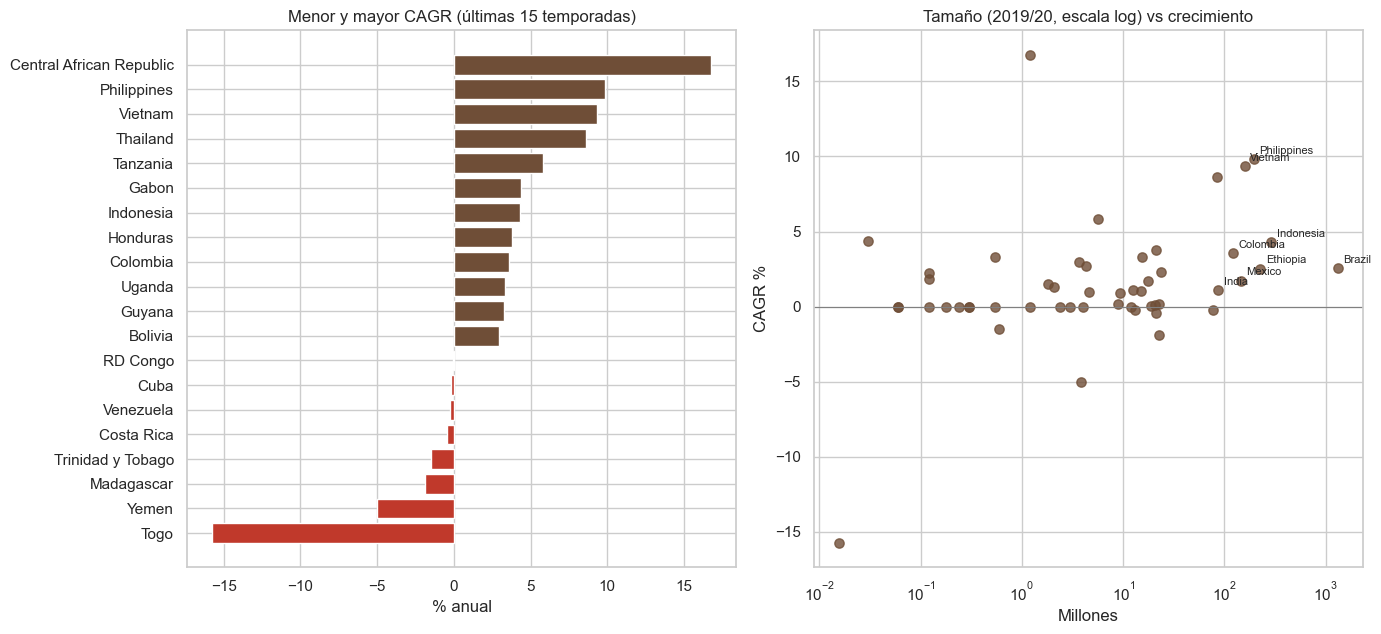

In [12]:
cagr = pd.Series({c: cagr_smooth(get_series(long, c).values[-15:]) for c in universe}).sort_values()
size_2019 = piv.loc[2019, universe]

fig, ax = plt.subplots(1, 2, figsize=(14, 6.5))
sel = pd.concat([cagr.head(8), cagr.tail(12)])
ax[0].barh(sel.index, sel.values * 100, color=np.where(sel.values >= 0, "#6f4e37", "#c0392b"))
ax[0].set(title="Menor y mayor CAGR (últimas 15 temporadas)", xlabel="% anual")

ax[1].scatter(size_2019, cagr.reindex(size_2019.index) * 100, s=45, color="#6f4e37", alpha=0.8)
for c in size_2019.nlargest(8).index:
    ax[1].annotate(c, (size_2019[c], cagr[c] * 100), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[1].set_xscale("log")
ax[1].axhline(0, color="grey", lw=0.8)
ax[1].set(title="Tamaño (2019/20, escala log) vs crecimiento", xlabel="Millones", ylabel="CAGR %")
plt.tight_layout()
save_fig("eda_crecimiento")
plt.show()

## 8. Los mayores mercados, uno a uno

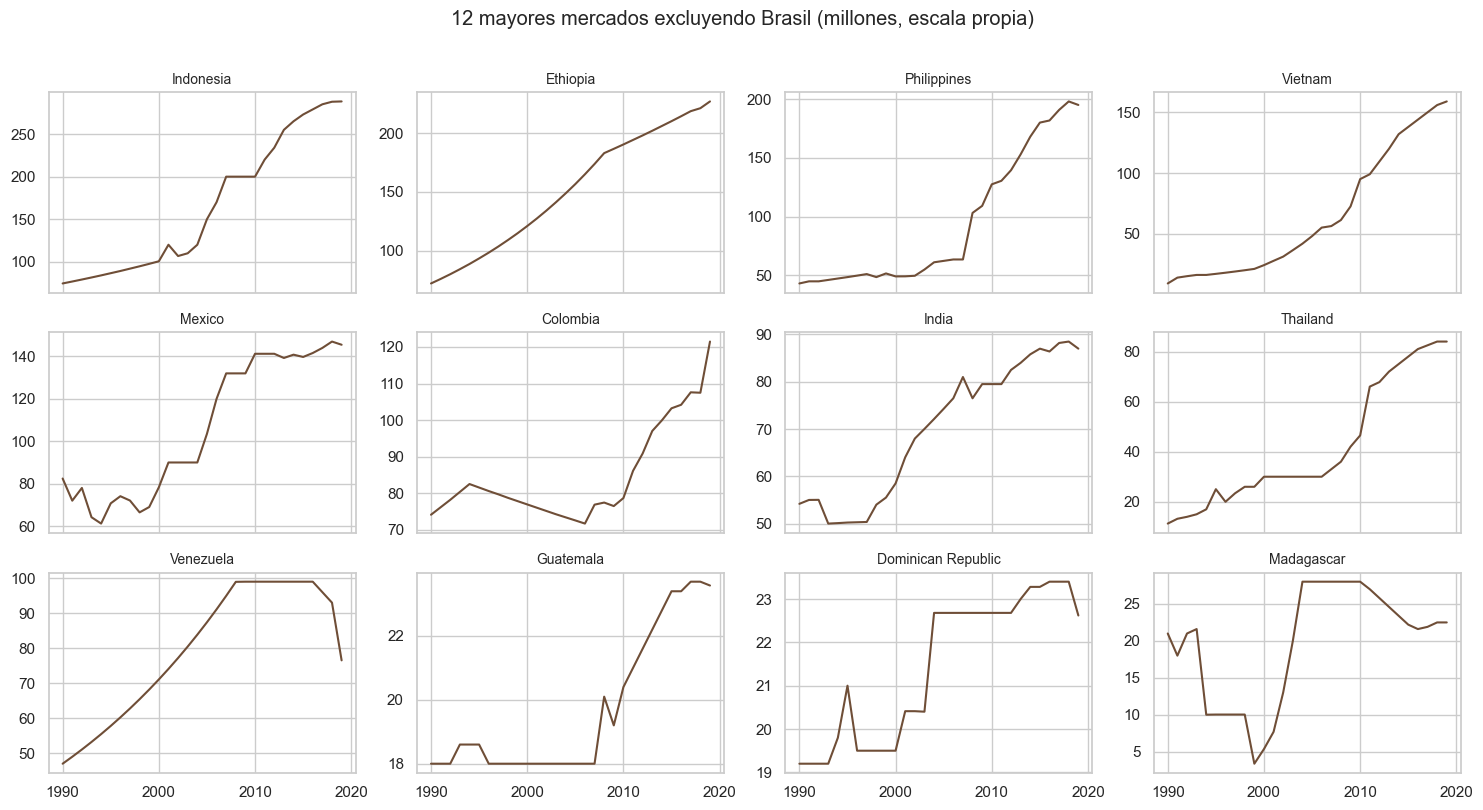

In [13]:
grandes = size_2019.drop("Brazil").nlargest(12).index
fig, axes = plt.subplots(3, 4, figsize=(15, 8), sharex=True)
for ax, c in zip(axes.ravel(), grandes):
    s = get_series(long, c)
    ax.plot(s.index, s.values, color="#6f4e37")
    ax.set_title(c, fontsize=10)
fig.suptitle("12 mayores mercados excluyendo Brasil (millones, escala propia)", y=1.01)
plt.tight_layout()
save_fig("eda_top12")
plt.show()

## 9. Hallazgos

1. **Crecimiento que se desacelera.** El consumo total pasó de 1,171 M a 2,999 M (×2.56, CAGR 3.3%), pero en los últimos 5 años crece solo 1.5% anual y en 2019/20 hay la primera caída de la serie (−0.5%).
2. **Muy concentrado.** Brasil es el 44% del consumo (42% en 1990), el top 5 suma 73% y el top 10 el 90%. Brasil además creció más rápido que el resto (×2.68 vs ×2.47). Cualquier métrica agregada está dominada por él.
3. **Tipo de café.** Lo "Mixto" (donde está Brasil) es el 79% del total. Sin Brasil, Arabica pasa de 42% a 34% y Mixto de 53% a 63%. Robusta puro es marginal (2–4%).
4. **Crecimiento muy heterogéneo.** Mediana de CAGR ≈ 1%: 31 países crecen, 8 caen y 12 están planos. Entre los mercados grandes destacan Filipinas (9.8%), Vietnam (9.3%), Tailandia (8.6%), Indonesia (4.3%) y Colombia (3.6%). República Centroafricana (16.8%) parte de una base minúscula; Togo (−15.7%) y Yemen (−5.0%) caen.
5. **Calidad del dato.** 55% de las variaciones anuales son exactamente cero y 21 países tienen ≥70% de años planos (pesan solo 3.5% del volumen). Hay que leer con cautela los pronósticos de esos países.
6. **Alcance.** Los 55 países son productores; el dato no incluye importadores ni precios. Esto acota lo que se puede afirmar: se puede hablar de **demanda interna en países productores**, no de precios futuros ni de mercados de importación.

**Siguiente:** `02_forecast.ipynb` (pronóstico a 5 temporadas) y `03_segmentation.ipynb` (segmentación de mercados). Son independientes entre sí.